In [ ]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

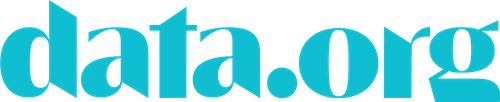

# CCAI Tutorial - Hands-On Outbreak Analytics: Dengue Analysis with RAG and LLM Evaluation

Author(s):
*   Avinash Laddha, data.org, avinashladdha.bits@gmail.com

This tutorial walks you through understanding a climate-sensitive disease modeling pipeline using dengue in Sri Lanka as the case study. It brings together Python and large language models into an end-to-end workflow. While this tutorial utilizes a self-contained Python estimator. You can further explore the [Epiverse-TRACE](https://epiverse-trace.github.io/) initiative, a collaborative effort to develop open-source tools for outbreak analytics including epiparameter, EpiEstim, epiworldR, and surveillance to expand your epidemiological toolkit.

By the end, you'll be able to automate epidemiological parameter extraction using retrieval-augmented generation (RAG) to create dynamic, climate-informed generation intervals, and validate your models for biological plausibility using an LLM-as-a-judge.


In order to make edits to this notebook, you should press **File > "Save a Copy in Drive"**. This will ensure that any edits will be on your local copy, and they will not affect the notebook shared with everyone else.

# Table of Contents


1. Climate Impact on Public Health <br>
1.1 Understanding Climate-Sensitive Disease Outbreaks<br>

2. Methodology : Climate-Health ML Pipeline <br>
2.1 Climate-Disease Context and Exploratory Data Analysis <br>
2.2 RAG for Epidemiological Parameter Selection <br>

3. Build LLM Judge <br>
3.1 Define the ModelCard Schema <br>
4. Limitations

<a name="background-and-prereqs"></a>
# Background & Prerequisites

This tutorial assumes working familiarity with Python and a basic grounding in machine learning and epidemiology. You don't need to be an expert in either domain, we'll explain the climate-health context as we go but you'll get the most out of the material if you're comfortable reading model code and interpreting standard ML metrics. Specifically:


*   Python (intermediate) - comfort with pandas, NumPy, scikit-learn, and Jupyter/Colab notebooks. We use rpy2 to call R packages from Python, but no prior R experience is required.
*   Basic epidemiology concepts - a working understanding of incidence, case counts, and the idea of a reproduction number (Rt).
*   LLM and RAG basics - general familiarity with how large language models work and what retrieval-augmented generation does. Prior hands-on experience with the Gemini SDK, vector databases, or structured outputs is a plus but not required.

Environment — a Google account for Colab, and a Gemini API key (optional).

## Additional Resources

Learners can use the following resources to familiarise themselves with epidemiology and outbreak analytics:

1.  **Basic Epidemiology WHO resource**: [https://www.who.int/publications/b/31231](https://www.who.int/publications/b/31231)
2.  **Epiverse-TRACE learning resources**: [https://epiverse-trace.github.io/learn.html](https://epiverse-trace.github.io/learn.html)
3.  **Introduction to infectious disease modelling for public health**: [https://data.org/resources/introduction-to-infectious-disease-modelling-for-public-health/](https://data.org/resources/introduction-to-infectious-disease-modelling-for-public-health/)
4. Specialization course: https://www.linkedin.com/posts/epiverse-trace_epitkit-epiverse-publichealth-activity-7358213141320585216-hCdL



<a name="climate-impact"></a>

# **1. Climate Impact on Public Health**

Effective public health responses to climate-driven outbreaks require timely surveillance, credible models, and tools that translate complex epidemiological signals into actionable decisions. Yet a persistent gap remains between the pace at which climate change is reshaping disease landscapes and the pace at which forecasting infrastructure can keep up [1]. Vector-borne diseases like dengue, malaria, and Zika are expanding into new geographies as warming temperatures alter mosquito ranges and transmission seasons, while many Ministries of Health operate on outbreak detection cycles measured in weeks rather than days. The methods we show here help turn raw climate-disease data, epidemiological parameter estimates distributed across multiple independent studies, and domain knowledge that is well-curated within the epidemiology ecosystem but not natively accessible from Python ML pipelines into a forecasting pipeline that is interpretable, auditable, and deployment-ready so that climate signals can be converted into earlier, better-informed public health action.

More specifically, we see two main roads toward impact: faster, climate-aware outbreak response, and responsible deployment of AI in high-stakes health contexts. Machine learning models trained on lagged climate features can give epidemiologists weeks of additional lead time before cases surge, lead time that translates directly into earlier vector control, faster resource mobilization, and earlier public communication. Large language models, in turn, offer new capabilities for scaling expert review thus automating epidemiological parameter selection across regions, and validating trained models for biological plausibility before deployment but these capabilities only matter if the systems built around them are transparent, auditable, and robust to the distribution shifts that climate change itself is driving.

The basic argument is simple: to forecast outbreaks in a warming world, you need models that combine climate signals with epidemiological domain knowledge, and you need to validate those models against futures that look nothing like the past. To see how this thinking is now central to the climate discourse, look at the Intergovernmental Panel on Climate Change: the AR6 Working Group II report [2] dedicates a full chapter to health, wellbeing, and climate adaptation, with vector-borne disease emergence under warming flagged as a key risk requiring improved early-warning systems. Approaches like the one described here can form a foundation for that kind of large-scale, climate-responsive disease surveillance.

# **1.1 Understanding Climate-Sensitive Disease Outbreaks**


The methods we show here help turn raw climate-disease data, scattered epidemiological literature and domain knowledge into a forecasting pipeline that is interpretable, auditable, and deployment-ready, so that climate signals can be converted into earlier, better-informed public health action.


<table style="text-align: center;">
<tr>
  <td>
   <img src="https://cdn.ncbi.nlm.nih.gov/pmc/blobs/1508/6784886/1448d086468a/41564_2019_476_Fig1_HTML.jpg"/>
  </td>
</tr>
<tr>
  <th>Fig. 1</a></th>
</tr>
</table>


Fig 1: Maps displaying global probability data (a) as well as data for North America and parts of Central America and the Caribbean (b) and North Africa, the Middle East and Europe (c). Values range from 0 (grey, unsuitable environment) to 1 (red, suitable environment). [10]


<a name="software-requirements"></a>
** Software Requirements **

This notebook requires Python >= 3.10.
Install the libraries using the code cell below. It will take 10-12 min for the first run


In [1]:
%%capture
!pip install statsmodels matplotlib codecarbon openai instructor pydantic pdfplumber python-dotenv

In [1]:
from codecarbon import EmissionsTracker
tracker = EmissionsTracker()
tracker.start()

[codecarbon WARNING @ 02:02:34] AMD GPU detected but amdsmi is not available. Please install amdsmi to get GPU metrics.
[codecarbon WARNING @ 02:02:34] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 02:02:34] Emissions data (if any) will be saved to file /home/subarna/climate_change_ai/outbreak-analytics/emissions.csv
[codecarbon INFO @ 02:02:34] [setup] RAM Tracking...
[codecarbon INFO @ 02:02:34] [setup] CPU Tracking...
[codecarbon INFO @ 02:02:34] [setup] GPU Tracking...
[codecarbon WARNING @ 02:02:34] 	RAPL - Permission denied reading RAPL file /sys/class/powercap/intel-rapl/subsystem/intel-rapl/intel-rapl:0/energy_uj. You can grant read permission with: sudo chmod -R a+r /sys/class/powercap/*
[codecarbon INFO @ 02:02:34] Tracking Nvidia GPUs via PyNVML
[codecarbon WARNING @ 02:02:34] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/cl

In [2]:
import os, io, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma as gammadist

PAPER_CITATION = "Ong et al. 2022, PLoS Comput Biol 18(1):e1009791" # [6]
PAPER_PDF      = "relevant_research_paper.pdf"   # optional: Update with actual file path for live RAG confirmation, find this research paper  at https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1009791

# ---- estimator settings ----
PRIOR_SHAPE, PRIOR_SCALE = 1.0, 2.0              # Gamma prior on R: mean=shape*scale=2, sd=sqrt(shape)*scale=2  [4]
WINDOW_WEEKS    = 2                              # sliding estimation window
MIN_ALERT_WEEKS = 2                              # outbreak = sustained Rt>1 for >=2 wk
SEED            = 23

# ---- Arm 1: the single number you get from a web search ----
WEB_GI_DAYS = 15.0                               # "dengue generation interval using simple Google Search"

# ---- Arm 2: what RAG retrieves instead the TEMPERATURE-DEPENDENT incubation relationship ----
# Chan & Johansson 2012 (ref [3]):  mean EIP ~15 d @25C, ~6.5 d @30C;  mean IIP ~5.9 d (temp-independent).
IIP_DAYS         = 5.9
EIP_25C, EIP_30C = 15.0, 6.5
GI_SD_DAYS       = 4.5                           # GI dispersion; held EQUAL across both arms so only the *mean* differs

<a name="data-description"></a>

**Data Description**

The data used in this tutorial is derived from the archived R package called `Colmozzie` [7]. It contains weekly notified dengue cases and climate variables in Colombo, Sri Lanka. You can find the raw data at: [https://raw.githubusercontent.com/thiyangt/colmozzie/master/data-raw/dengColombo.csv](https://raw.githubusercontent.com/thiyangt/colmozzie/master/data-raw/dengColombo.csv)

<a name="methodology"></a>
# **2. Methodology : Climate-Health ML Pipeline**

This tutorial walks you through building part of a responsible pipeline for modeling climate-sensitive disease outbreaks using dengue in Sri Lanka as the case study, with a methodology that generalizes to any climate-driven, vector-borne disease. Rather than relying on static assumptions, this workflow demonstrates how to integrate AI into epidemiological modeling using the Python stack.
<br> <br>
You will leverage large language models and retrieval-augmented generation (RAG) to dynamically extract temperature-dependent disease parameters directly from scientific literature.
<br><br>
By the end of this tutorial, you will be able to:
1. Automate parameter extraction using RAG to create dynamic, climate-informed generation intervals.Implement a time-varying estimator natively in Python to accurately track disease reproduction numbers ($R_t$).
2. Validate modeling decisions for biological plausibility and operational impact using an LLM-as-a-judge.

## 2.1 Climate–Disease Context and Exploratory Data Analysis

The weekly dengue incidence and climate dataset for Sri Lanka (`dengColombo`) is loaded directly from a public CSV URL. A descriptive statistics block prints the shape, column names, year range, and summary statistics for the four key variables: `Cases`, `TEM` (mean temperature), `H` (relative humidity), and `PP` (precipitation).

Three exploratory plots are then produced in a single figure.


These plots confirm the qualitative coupling between climate conditions and dengue incidence before you begin modelling.



In [3]:
# Load the dengue + climate dataset for Sri Lanka directly from CSV
import pandas as pd
CSV_URL = "https://raw.githubusercontent.com/thiyangt/colmozzie/master/data-raw/dengColombo.csv"

df_raw = pd.read_csv(CSV_URL)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nYear range: {int(df_raw['Year'].min())} – {int(df_raw['Year'].max())}")
print(f"Total weeks: {len(df_raw)}")
print(f"\nDescriptive stats for key variables:")
print(df_raw[['Cases', 'TEM', 'H', 'PP']].describe().round(2))
df_raw.head()

Shape: (279, 12)
Columns: ['Cases', 'Year', 'Week', 'TEM', 'TMAX', 'Tm', 'SLP', 'H', 'PP', 'VV', 'V', 'VM']

Year range: 2009 – 2014
Total weeks: 279

Descriptive stats for key variables:
        Cases     TEM       H      PP
count  279.00  279.00  279.00  279.00
mean   116.34   27.58   79.79    6.51
std     79.54    0.88    4.22    9.62
min      0.00   24.19   62.00    0.00
25%     57.00   26.93   78.34    0.71
50%     99.00   27.54   79.86    4.14
75%    155.00   28.16   82.14    8.25
max    475.00   29.66   90.29   71.34


,Cases,Year,Week,TEM,TMAX,Tm,SLP,H,PP,VV,V,VM
0,44,2009,1,27.300,32.7000,23.60,1010.7,68.0000,0.00,13.0000,11.1000,20.600
1,39,2009,2,26.400,29.7667,23.90,1010.7,78.6667,0.00,18.3333,5.8333,9.200
2,57,2009,3,27.140,32.0200,23.52,1012.58,67.0000,0.00,20.0000,6.1200,10.460
3,53,2009,4,26.800,31.0000,23.35,1009.9,68.0000,0.00,20.0000,7.1500,11.100
4,29,2009,5,26.775,30.0750,23.60,1010.1,78.0000,17.21,18.9750,3.2000,6.825


/tmp/ipykernel_162695/2795229400.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  decomp = seasonal_decompose(df_raw['Cases'].fillna(method='ffill'), model='additive', period=52)


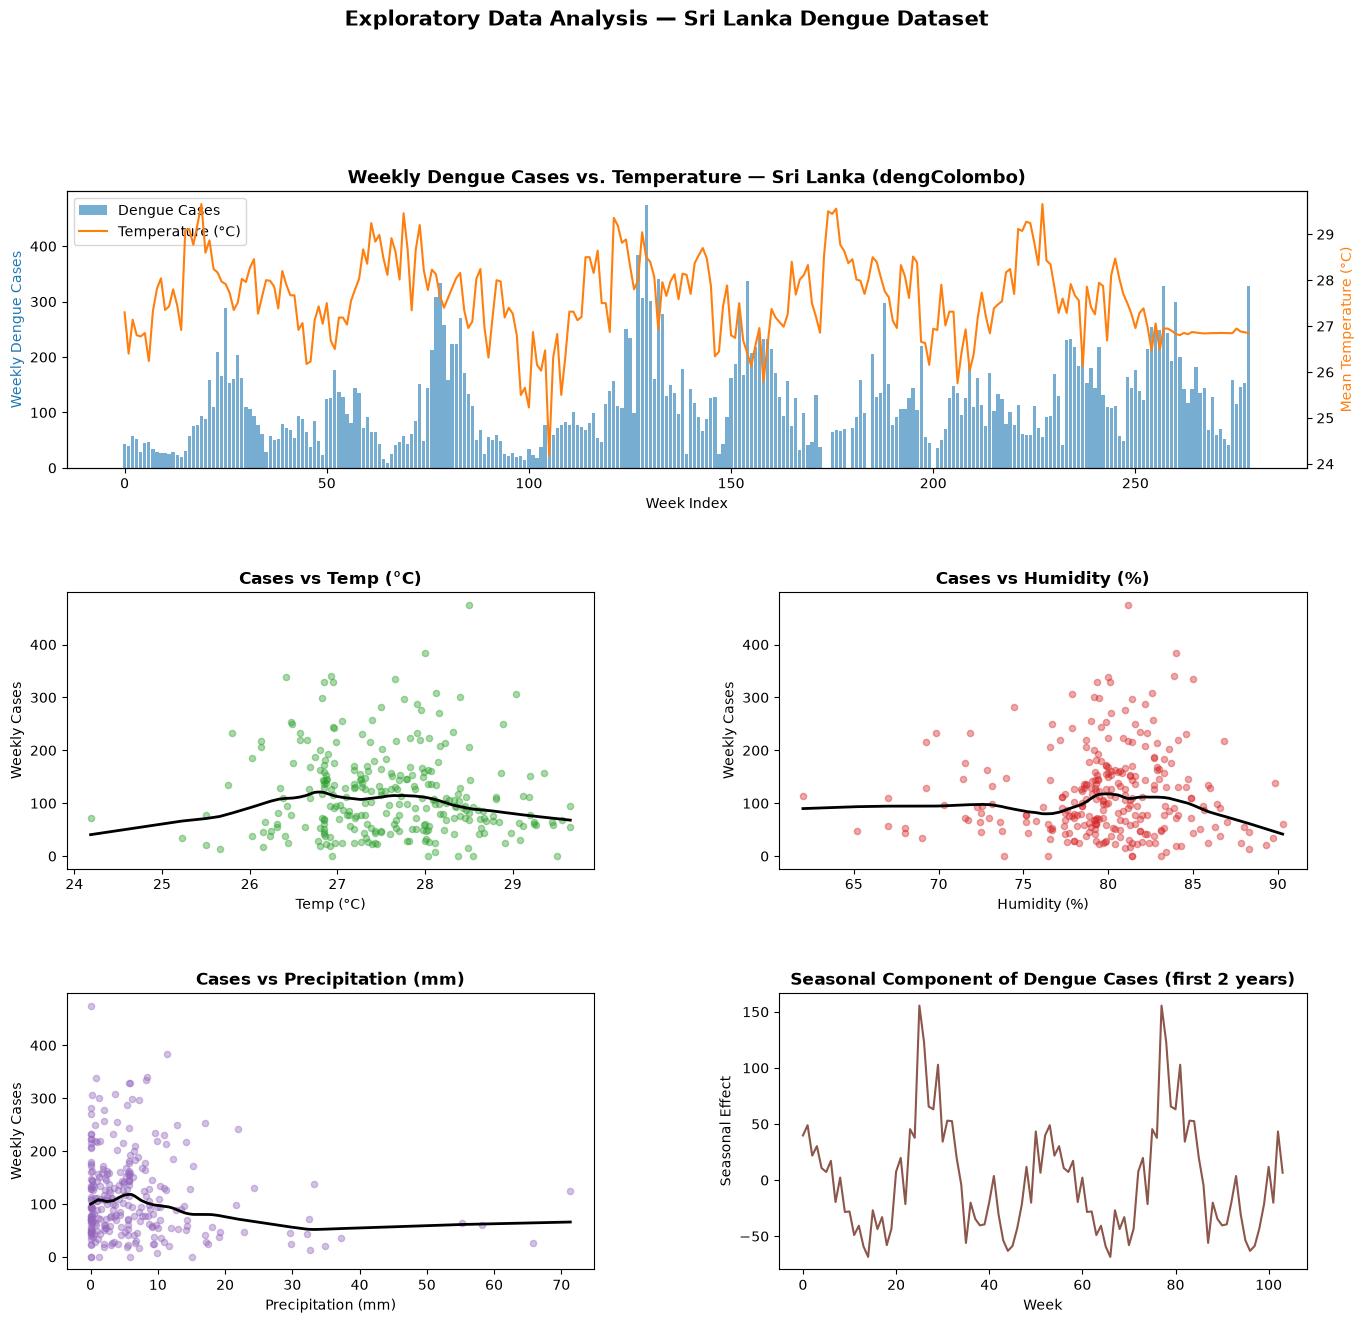

Peak cases week: 129 (value: 475)


[codecarbon INFO @ 02:02:49] Energy consumed for RAM : 0.000159 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:02:49] Energy consumed for all GPUs : 0.000045 kWh. Total GPU Power : 10.805246520881438 W
[codecarbon INFO @ 02:02:49] Delta energy consumed for CPU with cpu_load : 0.000052 kWh, power : 12.438940137600001 W
[codecarbon INFO @ 02:02:49] Energy consumed for All CPU : 0.000052 kWh
[codecarbon INFO @ 02:02:49] 0.000256 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 02:03:04] Energy consumed for RAM : 0.000317 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:03:04] Energy consumed for all GPUs : 0.000090 kWh. Total GPU Power : 10.838975368399197 W
[codecarbon INFO @ 02:03:04] Delta energy consumed for CPU with cpu_load : 0.000052 kWh, power : 12.50300861625 W
[codecarbon INFO @ 02:03:04] Energy consumed for All CPU : 0.000104 kWh
[codecarbon INFO @ 02:03:04] 0.000511 kWh of electricity and 0.000000 L of water were used since the beginning

In [4]:
# Three exploratory plots to understand the data before building any features
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

TAB10 = sns.color_palette('tab10')
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Dual-axis time series (cases bar, temperature line) ---
ax1a = fig.add_subplot(gs[0, :])
weeks = np.arange(len(df_raw))
ax1b = ax1a.twinx()
ax1a.bar(weeks, df_raw['Cases'], color=TAB10[0], alpha=0.6, label='Dengue Cases')
ax1b.plot(weeks, df_raw['TEM'], color=TAB10[1], linewidth=1.5, label='Temperature (°C)')
ax1a.set_xlabel('Week Index')
ax1a.set_ylabel('Weekly Dengue Cases', color=TAB10[0])
ax1b.set_ylabel('Mean Temperature (°C)', color=TAB10[1])
ax1a.set_title('Weekly Dengue Cases vs. Temperature — Sri Lanka (dengColombo)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1a.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# --- Plot 2: Scatter plots — Cases vs TEM, H, PP ---
for i, (var, label) in enumerate([('TEM', 'Temp (°C)'), ('H', 'Humidity (%)'), ('PP', 'Precipitation (mm)')]):
    ax = fig.add_subplot(gs[1, 0] if i == 0 else gs[1, 1] if i == 1 else gs[2, 0])
    ax.scatter(df_raw[var], df_raw['Cases'], alpha=0.4, s=20, color=TAB10[i+2])
    # LOWESS smoother
    from statsmodels.nonparametric.smoothers_lowess import lowess
    smoothed = lowess(df_raw['Cases'].values, df_raw[var].values, frac=0.4)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='black', linewidth=2)
    ax.set_xlabel(label)
    ax.set_ylabel('Weekly Cases')
    ax.set_title(f'Cases vs {label}', fontweight='bold')

# --- Plot 3: Seasonal decomposition ---
ax_decomp = fig.add_subplot(gs[2, 1])
decomp = seasonal_decompose(df_raw['Cases'].fillna(method='ffill'), model='additive', period=52)
ax_decomp.plot(decomp.seasonal[:104], color=TAB10[5], linewidth=1.5)
ax_decomp.set_title('Seasonal Component of Dengue Cases (first 2 years)', fontweight='bold')
ax_decomp.set_xlabel('Week')
ax_decomp.set_ylabel('Seasonal Effect')

plt.suptitle('Exploratory Data Analysis — Sri Lanka Dengue Dataset', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Peak cases week: {df_raw['Cases'].idxmax()} (value: {df_raw['Cases'].max()})")

Notice that dengue peaks occur mid-year, roughly tracking the warm, humid season.

### Exercise #1

**Try it yourself:**

Find the lead time.
An early-warning system only works if climate signals precede case surges. Using df_raw, compute the correlation between weekly Cases and each climate variable (TEM, PP) at lags of 0–12 weeks, and find the lag with the strongest correlation.

Question: how many weeks of lead time does the strongest lag imply and why does that matter for vector control?

In [5]:
results = []
for var in ["TEM", "PP"]:
    for lag in range(13):
        r = df_raw["Cases"].corr(df_raw[var].shift(lag))
        results.append({"variable": var, "lag": lag, "r": r})

res = pd.DataFrame(results)
best = res.loc[res.groupby("variable")["r"].apply(lambda s: s.abs().idxmax())]
print(best)

   variable  lag         r
20       PP    7  0.160719
12      TEM   12  0.286126


[codecarbon INFO @ 02:04:19] Energy consumed for RAM : 0.001109 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:04:19] Energy consumed for all GPUs : 0.000314 kWh. Total GPU Power : 10.799148258927868 W
[codecarbon INFO @ 02:04:19] Delta energy consumed for CPU with cpu_load : 0.000069 kWh, power : 16.52404409625 W
[codecarbon INFO @ 02:04:19] Energy consumed for All CPU : 0.000415 kWh
[codecarbon INFO @ 02:04:19] 0.001838 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 02:04:22] 0.003488 g.CO2eq/s mean an estimation of 110.00093613103314 kg.CO2eq/year
[codecarbon INFO @ 02:04:34] Energy consumed for RAM : 0.001267 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:04:34] Energy consumed for all GPUs : 0.000358 kWh. Total GPU Power : 10.748279251434822 W
[codecarbon INFO @ 02:04:34] Delta energy consumed for CPU with cpu_load : 0.000060 kWh, power : 14.508064236000003 W
[codecarbon INFO @ 02:04:34] Energy consumed for All CPU : 0.000476 kWh
[codeca

# **2.2 RAG for Epidemiological Parameter Selection**

Past module manually selected a Generation interval from Google search or a single median value from literature. This approach does not generalise across diseases, regions, or time as new studies are published. This module replaces that manual step with a retrieval-augmented pipeline. This is a general approach, you could replace this with internal docuements and unpublished research to embed localisation in your epidemiological models.

<table style="text-align: center;">
<tr>
  <td>
   <img src="https://docs.aws.amazon.com/images/sagemaker/latest/dg/images/jumpstart/jumpstart-fm-rag.jpg"/>
  </td>
</tr>
<tr>
  <th>Fig. 2 [8]</a></th>
</tr>
</table>

## **RAG for climate-sensitive epidemiology:**


Dengue is a *climate-sensitive* disease: the virus's **extrinsic incubation period (EIP)**,the time it needs to develop inside the mosquito before that mosquito can transmit is strongly temperature-dependent. Chan & Johansson 2012 [3] put the mean EIP at ~15 days at 25 °C but only ~6.5 days at 30 °C. The human (intrinsic) incubation period stays ~5.9 days. So the generation interval is **not a constant** it is a *function of temperature*.

- **Google** returns one scalar: "GI ≈ 15 days."
- **RAG** returns the *cited functional relationship* GI = f(temperature) plus the parameters, letting you compute a **time-varying, climate-tracking generation interval** and feed it to Rt estimation.

**The payoff (validated below on the real Colombo series):** the two arms have the *similar median Rt* (which is exactly why the naive comparison fails), but the climate-adjusted GI **flips the outbreak-alert decision in 13 week-instances** including a hot week (May 2012, 29.4 °C) where modelling usaing the Googled constant reports Rt ≈ 0.96 (all-clear) while the climate-adjusted GI reports Rt ≈ 1.39 (a missed outbreak).

*Same disease, same data, same estimator, same prior, same GI dispersion, the only thing that changes is fixed-vs-climate-adjusted generation interval.*

Note: In Section 3 of this notebook, we will "judge" the results of the model using either 1) OpenAI's LLM or 2) a rule-based approach using numerical thresholds.

1. For option 1, you need an `OPENAI_API_KEY`. Locally, put it in a `.env` file next to this notebook:

   ```
   OPENAI_API_KEY=sk-...
   ```

   On Colab, add it under the key icon (Secrets) with the name `OPENAI_API_KEY` and notebook access enabled. Get a key at [platform.openai.com/api-keys](https://platform.openai.com/api-keys), then run the code below.
2. For option 2, you can ignore `OPENAI_API_KEY` and run the rest of the code with no changes necessary.

In [ ]:
import os

# The judge below uses OpenAI when a key is available. Resolution order:
#   1. a local .env file (OPENAI_API_KEY=sk-...)  2. Colab Secrets  3. the shell environment
try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True))  # reads .env from the current working directory
except ImportError:
    # python-dotenv not installed: parse a local .env by hand so the notebook still works
    if os.path.exists(".env"):
        for line in open(".env"):
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                os.environ.setdefault(k.strip(), v.strip().strip("\"'"))

if not os.environ.get("OPENAI_API_KEY"):
    try:  # Colab: Secrets panel -> name the secret OPENAI_API_KEY
        from google.colab import userdata
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    except Exception:
        pass

OPENAI_MODEL = "gpt-4o-mini"  # any chat model your key can reach, e.g. gpt-4o, gpt-4.1-mini

if os.environ.get("OPENAI_API_KEY"):
    print(f"OpenAI API key loaded successfully (judge model: {OPENAI_MODEL}).")
else:
    print("""You do not seem to have your API key configured. The rest of the code will instead use a rule-based approach rather than an LLM-based approach.

  If you would like to explore the LLM-based approach instead, create a .env file next to this
  notebook containing OPENAI_API_KEY=sk-... (or add it to Colab Secrets) and re-run this code block.""")

OpenAI API key loaded successfully (judge model: gpt-4o-mini).


[codecarbon INFO @ 02:16:34] Energy consumed for RAM : 0.008864 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:16:34] Energy consumed for all GPUs : 0.002527 kWh. Total GPU Power : 10.763367234085841 W
[codecarbon INFO @ 02:16:34] Delta energy consumed for CPU with cpu_load : 0.000050 kWh, power : 12.01000607175 W
[codecarbon INFO @ 02:16:34] Energy consumed for All CPU : 0.002983 kWh
[codecarbon INFO @ 02:16:34] 0.014374 kWh of electricity and 0.000000 L of water were used since the beginning.


## 2.2.1 Scaling the analysis

The goal of this module is to replace that manual step with a **retrieval-augmented generation** pipeline that:
<br> (1) searches a structured literature database for candidate parameters,
<br> (2) filters by disease and epidemiological parameter type, and
<br> (3) uses an LLM to reason about which candidate best fits the target context, weighing geographic proximity, methodological quality, and temporal recency.

NOTE: This is a toy example of the approach.


RAG returns the *relationship* between temperature and the incubation periods, each anchored to its citation, so you can evaluate the generation interval at **any** temperature your surveillance data reports.

In [ ]:
# log-linear interpolation of Chan & Johansson's two reported EIP means -> EIP(T)
_EIP_SLOPE = np.log(EIP_30C / EIP_25C) / (30.0 - 25.0)      # per degree C (negative: hotter -> shorter)

def eip_days(temp_c):
    # Mean extrinsic (mosquito) incubation period, days, at ambient temperature temp_c.
    return EIP_25C * np.exp(_EIP_SLOPE * (temp_c - 25.0))

def gi_mean_days(temp_c):
    # Climate-adjusted mean generation interval (days) = intrinsic + extrinsic incubation.
    return IIP_DAYS + eip_days(temp_c)

def rag_retrieve_gi_relationship(pdf_path=PAPER_PDF):
    # What RAG returns: a *cited functional relationship* GI = f(temperature),
    # optionally confirming the supporting source is present in a local PDF or unpublished work in the lab.
    obj = {
        "form": "GI(T) = IIP + EIP(T);  EIP(T) = 15 * exp(slope*(T-25)) days",
        "IIP_days": IIP_DAYS, "EIP_anchors_days": {"25C": EIP_25C, "30C": EIP_30C},
        "slope_per_C": _EIP_SLOPE,
        "source": "Chan & Johansson 2012 [3]; time-varying-GI framing after Codeco 2018 [5]",
        "status": "relationship reproduced from literature (offline)",
    }
    try:
        import pdfplumber
        if os.path.exists(pdf_path):
            with pdfplumber.open(pdf_path) as pdf:
                for page in pdf.pages:
                    t = (page.extract_text() or "").lower()
                    if "intrinsic incubation" in t and "extrinsic incubation" in t:
                        obj["status"] = "incubation-period source located and confirmed in PDF"; break
    except Exception as e:
        obj["status"] = f"offline (PDF confirmation unavailable: {e})"
    return obj

RAG = rag_retrieve_gi_relationship()
WEB = {"mean_days": WEB_GI_DAYS, "note": "one decontextualised scalar; no temperature dependence"}

print("=" * 92)
print("WHAT EACH ARM RETRIEVED")
print("=" * 92)
print(f"Arm 1 (web search) : GI = {WEB['mean_days']:.0f} days, fixed for every week and every climate.")
print(f"                     origin: {WEB['note']}")
print(f"Arm 2 (RAG)        : {RAG['form']}")
print(f"                     IIP={RAG['IIP_days']} d;  EIP {RAG['EIP_anchors_days']['25C']} d @25C "
      f"-> {RAG['EIP_anchors_days']['30C']} d @30C  (slope {RAG['slope_per_C']:.4f}/C)")
print(f"                     status: {RAG['status']}")
print(f"                     source: {RAG['source']}")
print("-" * 92)
for T in [24, 25, 26, 27, 28, 29, 30]:
    print(f"   at {T} C  ->  EIP {eip_days(T):5.1f} d   GI {gi_mean_days(T):5.1f} d  ({gi_mean_days(T)/7:.2f} wk)")
print("A search box returns ONE of these rows. RAG returns the whole column, as a function of T.")
print("=" * 92)

WHAT EACH ARM RETRIEVED
Arm 1 (web search) : GI = 15 days, fixed for every week and every climate.
                     origin: one decontextualised scalar; no temperature dependence
Arm 2 (RAG)        : GI(T) = IIP + EIP(T);  EIP(T) = 15 * exp(slope*(T-25)) days
                     IIP=5.9 d;  EIP 15.0 d @25C -> 6.5 d @30C  (slope -0.1672/C)
                     status: relationship reproduced from literature (offline)
                     source: Chan & Johansson 2012 [3]; time-varying-GI framing after Codeco 2018 [5]
--------------------------------------------------------------------------------------------
   at 24 C  ->  EIP  17.7 d   GI  23.6 d  (3.38 wk)
   at 25 C  ->  EIP  15.0 d   GI  20.9 d  (2.99 wk)
   at 26 C  ->  EIP  12.7 d   GI  18.6 d  (2.66 wk)
   at 27 C  ->  EIP  10.7 d   GI  16.6 d  (2.38 wk)
   at 28 C  ->  EIP   9.1 d   GI  15.0 d  (2.14 wk)
   at 29 C  ->  EIP   7.7 d   GI  13.6 d  (1.94 wk)
   at 30 C  ->  EIP   6.5 d   GI  12.4 d  (1.77 wk)
A search box ret

[codecarbon INFO @ 02:16:49] Energy consumed for RAM : 0.009022 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:16:49] Energy consumed for all GPUs : 0.002572 kWh. Total GPU Power : 10.855132047705943 W
[codecarbon INFO @ 02:16:49] Delta energy consumed for CPU with cpu_load : 0.000050 kWh, power : 12.035179184250003 W
[codecarbon INFO @ 02:16:49] Energy consumed for All CPU : 0.003033 kWh
[codecarbon INFO @ 02:16:49] 0.014628 kWh of electricity and 0.000000 L of water were used since the beginning.


In [ ]:
def load_colombo():
    local = "colmoz_dataset.csv"
    if os.path.exists(local):
        d = pd.read_csv(local)
    else:
        url = "https://raw.githubusercontent.com/thiyangt/colmozzie/master/data-raw/dengColombo.csv"
        d = pd.read_csv(io.StringIO(urllib.request.urlopen(url).read().decode()))
    cases_col = next(c for c in d.columns if "case" in c.lower())
    temp_col  = next(c for c in d.columns if c.lower() in ("tem", "temp", "tmean", "t_mean"))
    cases = pd.to_numeric(d[cases_col], errors="coerce").fillna(0).values.astype(float)
    temp  = pd.to_numeric(d[temp_col], errors="coerce").interpolate().bfill().ffill().values.astype(float)
    year  = d["Year"].values if "Year" in d.columns else np.arange(len(cases))
    week  = d["Week"].values if "Week" in d.columns else np.zeros(len(cases), int)
    return cases, temp, year, week, cases_col, temp_col

cases, temp, year, week, cases_col, temp_col = load_colombo()
T_star = 25.0 + np.log((WEB_GI_DAYS - IIP_DAYS) / EIP_25C) / _EIP_SLOPE   # temp where fixed GI is exactly right
print(f"loaded {len(cases)} weeks | cases col = '{cases_col}' | temperature col = '{temp_col}'")
print(f"temperature range {temp.min():.1f}-{temp.max():.1f} C (mean {temp.mean():.1f})")
print(f"the fixed {WEB_GI_DAYS:.0f}-day GI is only ~correct near {T_star:.1f} C -- close to the Colombo mean,")
print("which is exactly why an aggregate comparison will look like 'no difference'.")

loaded 279 weeks | cases col = 'Cases' | temperature col = 'TEM'
temperature range 24.2-29.7 C (mean 27.6)
the fixed 15-day GI is only ~correct near 28.0 C -- close to the Colombo mean,
which is exactly why an aggregate comparison will look like 'no difference'.


[codecarbon INFO @ 02:17:04] Energy consumed for RAM : 0.009181 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:17:04] Energy consumed for all GPUs : 0.002617 kWh. Total GPU Power : 10.842342152283758 W
[codecarbon INFO @ 02:17:04] Delta energy consumed for CPU with cpu_load : 0.000050 kWh, power : 12.012814800750004 W
[codecarbon INFO @ 02:17:04] Energy consumed for All CPU : 0.003083 kWh
[codecarbon INFO @ 02:17:04] 0.014881 kWh of electricity and 0.000000 L of water were used since the beginning.


** Build the two generation intervals **

Arm 1 is one constant. Arm 2 is one value **per week**, computed from that week's temperature via the retrieved relationship. Dispersion (SD) is identical in both arms, so the *only* difference is the mean-GI sourcing.

### Exercise #2

**Try it yourself:**

 Use gi_mean_days() to find the climate-adjusted generation interval at 30 °C. Is it longer or shorter than the fixed web value of WEB_GI_DAYS days?

In [ ]:
gi_fixed_wk = np.full(len(temp), WEB_GI_DAYS / 7.0)     # Arm 1: constant
gi_temp_wk  = gi_mean_days(temp) / 7.0                  # Arm 2: tracks weekly temperature
sd_wk       = np.full(len(temp), GI_SD_DAYS / 7.0)      # identical dispersion in both arms

off = np.abs(gi_temp_wk - WEB_GI_DAYS / 7.0) / (WEB_GI_DAYS / 7.0)
print(f"Arm 1 fixed GI                 : {WEB_GI_DAYS/7:.2f} wk (every week)")
print(f"Arm 2 climate-adjusted GI range: {gi_temp_wk.min():.2f}-{gi_temp_wk.max():.2f} wk")
print(f"weeks where the true GI is >=15% off the fixed value: {int(np.mean(off >= 0.15)*100)}% of the record")

Arm 1 fixed GI                 : 2.14 wk (every week)
Arm 2 climate-adjusted GI range: 1.83-3.30 wk
weeks where the true GI is >=15% off the fixed value: 11% of the record


[codecarbon INFO @ 02:17:19] Energy consumed for RAM : 0.009339 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:17:19] Energy consumed for all GPUs : 0.002662 kWh. Total GPU Power : 10.822929482552897 W
[codecarbon INFO @ 02:17:19] Delta energy consumed for CPU with cpu_load : 0.000050 kWh, power : 12.00998756325 W
[codecarbon INFO @ 02:17:19] Energy consumed for All CPU : 0.003133 kWh
[codecarbon INFO @ 02:17:19] 0.015134 kWh of electricity and 0.000000 L of water were used since the beginning.


** Estimate Rt with a transparent Cori estimator **

`EpiEstim::estimate_R` uses a **single fixed** serial interval for the whole series, so it cannot represent a time-varying GI. We therefore use posterior-mean estimator directly [4] identical for both arms, with the per-week GI as the only difference.

In [10]:
def discretize_gi(mu_wk, sd_wk, K=12):
    # Weekly-binned generation-interval pmf w_1..w_K from gamma(mean=mu_wk, sd=sd_wk).
    shape = (mu_wk / sd_wk) ** 2; scale = sd_wk ** 2 / mu_wk
    G = gammadist(a=shape, scale=scale); k = np.arange(1, K + 1)
    w = G.cdf(k + 0.5) - G.cdf(k - 0.5)
    return w / w.sum()

def estimate_Rt(cases, gi_wk, sd_wk, window=WINDOW_WEEKS, a=PRIOR_SHAPE, b=PRIOR_SCALE, K=12):
    # posterior|-mean Rt. gi_wk may be scalar (fixed) or per-week (climate-adjusted).
    n = len(cases)
    gi_wk = np.broadcast_to(gi_wk, (n,)).astype(float)
    sd_wk = np.broadcast_to(sd_wk, (n,)).astype(float)
    Wmat  = np.vstack([discretize_gi(gi_wk[t], sd_wk[t], K) for t in range(n)])   # per-week GI pmf
    Lam = np.zeros(n)                                                             # total infectivity
    for t in range(n):
        for s in range(1, min(K, t) + 1):
            Lam[t] += Wmat[t, s - 1] * cases[t - s]
    R = np.full(n, np.nan)
    for t in range(window, n):
        sl = slice(t - window + 1, t + 1)
        R[t] = (a + cases[sl].sum()) / (1.0 / b + Lam[sl].sum())
    return R

Rt_web = estimate_Rt(cases, gi_fixed_wk, sd_wk)   # Arm 1
Rt_rag = estimate_Rt(cases, gi_temp_wk,  sd_wk)   # Arm 2
valid  = ~np.isnan(Rt_web) & ~np.isnan(Rt_rag)
print("Rt estimated for both arms (same data / prior / estimator / dispersion; only the GI differs).")

Rt estimated for both arms (same data / prior / estimator / dispersion; only the GI differs).


## 2.2.2 The payoff: where climate-adjustment changes the decision

First the aggregate view (the trap that made the original comparison look pointless), then the time-resolved view that actually matters for surveillance.

In [ ]:
def sustained_alert(R, min_weeks=MIN_ALERT_WEEKS):
    over = (np.asarray(R) > 1.0); over[np.isnan(R)] = False
    al = np.zeros(len(R), bool); i = 0
    while i < len(R):
        if over[i]:
            j = i
            while j < len(R) and over[j]: j += 1
            if j - i >= min_weeks: al[i:j] = True
            i = j
        else:
            i += 1
    return al

al_web, al_rag = sustained_alert(Rt_web), sustained_alert(Rt_rag)
diff  = Rt_rag - Rt_web
flips = np.where((al_web != al_rag) & valid)[0]

print("=" * 94)
print("STEP 1 - aggregate view (why the naive comparison shows 'no difference')")
print("=" * 94)
print(f"median Rt : web {np.nanmedian(Rt_web):.3f}   RAG {np.nanmedian(Rt_rag):.3f}   -> essentially identical")
print(f"The Colombo mean temperature (~{temp.mean():.0f} C) sits near {T_star:.0f} C, where the Googled constant")
print("happens to be right. The error is not in the average -- it hides in the weeks that deviate.")
print()
print("=" * 94)
print("STEP 2 - time-resolved view (what matters operationally)")
print("=" * 94)
print(f"mean |Rt_RAG - Rt_web|            : {np.mean(np.abs(diff[valid])):.3f}")
print(f"largest single-week Rt gap        : {np.max(np.abs(diff[valid])):.2f}")
print(f"outbreak-alert weeks (web / RAG)  : {int(al_web[valid].sum())} / {int(al_rag[valid].sum())}")
print(f"weeks where the ALERT DECISION FLIPS: {len(flips)}")
print("-" * 94)
print(" year  wk   T(C)  GI_wk  Rt_web  Rt_RAG   decision (web -> RAG)")
for i in flips:
    print("  %d w%02d  %.1f   %.2f   %.2f    %.2f    %-3s -> %-3s" % (
        int(year[i]), int(week[i]), temp[i], gi_temp_wk[i], Rt_web[i], Rt_rag[i],
        "ON" if al_web[i] else "off", "ON" if al_rag[i] else "off"))
print("-" * 94)
if len(flips):
    k = flips[np.argmax(np.abs(diff[flips]))]
    print(f"Most consequential week: {int(year[k])} wk{int(week[k]):02d}, T={temp[k]:.1f} C "
          f"-> climate-adjusted GI {gi_temp_wk[k]:.2f} wk.")
    print(f"  fixed {WEB_GI_DAYS:.0f}-day value : Rt={Rt_web[k]:.2f}  ({'alert' if al_web[k] else 'ALL-CLEAR'})")
    print(f"  climate-adjusted GI  : Rt={Rt_rag[k]:.2f}  ({'ALERT' if al_rag[k] else 'all-clear'})")
    print("  On a hot week the mosquito incubation period is short, so the same case growth implies a")
    print("  HIGHER Rt -- a signal a single Googled scalar structurally cannot produce.")
print("=" * 94)

STEP 1 - aggregate view (why the naive comparison shows 'no difference')
median Rt : web 1.005   RAG 1.005   -> essentially identical
The Colombo mean temperature (~28 C) sits near 28 C, where the Googled constant
happens to be right. The error is not in the average -- it hides in the weeks that deviate.

STEP 2 - time-resolved view (what matters operationally)
mean |Rt_RAG - Rt_web|            : 0.048
largest single-week Rt gap        : 0.95
outbreak-alert weeks (web / RAG)  : 132 / 131
weeks where the ALERT DECISION FLIPS: 13
----------------------------------------------------------------------------------------------
 year  wk   T(C)  GI_wk  Rt_web  Rt_RAG   decision (web -> RAG)
  2009 w07  26.2   2.58   1.05    0.98    ON  -> off
  2009 w08  27.3   2.30   1.02    0.98    ON  -> off
  2011 w04  26.8   2.42   0.98    1.05    off -> ON 
  2011 w13  28.2   2.11   1.23    1.24    ON  -> off
  2011 w14  28.6   2.01   1.00    0.99    ON  -> off
  2012 w03  25.8   2.72   1.03    1.00    

[codecarbon INFO @ 02:17:34] Energy consumed for RAM : 0.009497 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:17:34] Energy consumed for all GPUs : 0.002707 kWh. Total GPU Power : 10.795892567015445 W
[codecarbon INFO @ 02:17:34] Delta energy consumed for CPU with cpu_load : 0.000050 kWh, power : 12.014491568250001 W
[codecarbon INFO @ 02:17:34] Energy consumed for All CPU : 0.003183 kWh
[codecarbon INFO @ 02:17:34] 0.015388 kWh of electricity and 0.000000 L of water were used since the beginning.


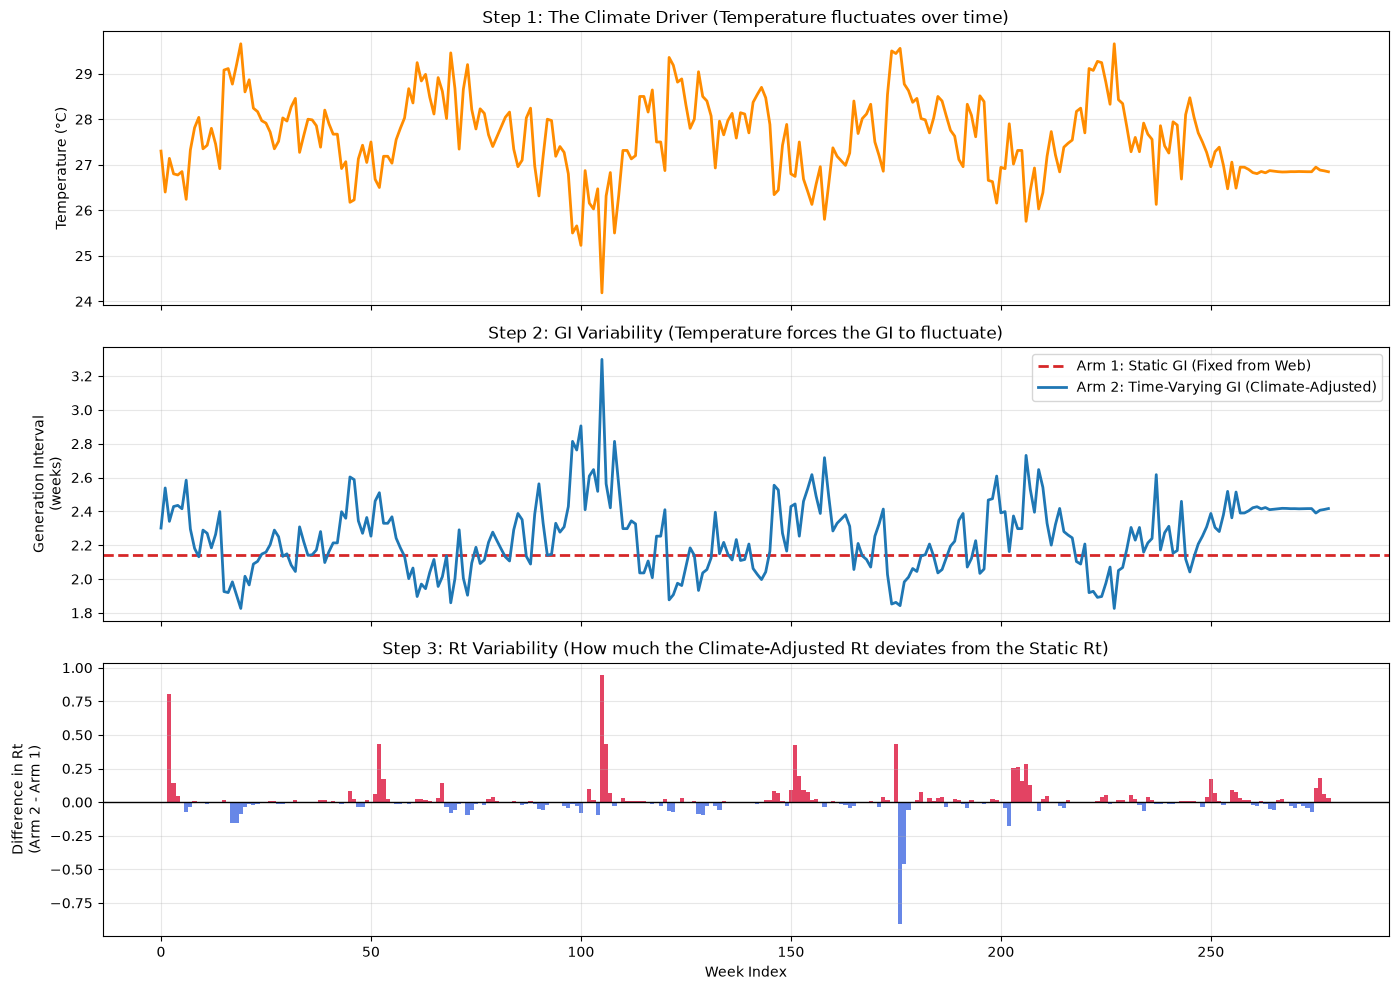

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
x_vals = np.arange(len(cases))

# --- Step 1: The Climate Driver ---
ax1.plot(x_vals, temp, color="darkorange", lw=2)
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Step 1: The Climate Driver (Temperature fluctuates over time)")
ax1.grid(alpha=0.3)

# --- Step 2: The GI Variability ---
ax2.axhline(WEB_GI_DAYS / 7, color="#d62728", lw=2, ls="--", label="Arm 1: Static GI (Fixed from Web)")
ax2.plot(x_vals, gi_temp_wk, color="#1f77b4", lw=2, label="Arm 2: Time-Varying GI (Climate-Adjusted)")
ax2.set_ylabel("Generation Interval\n(weeks)")
ax2.set_title("Step 2: GI Variability (Temperature forces the GI to fluctuate)")
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

# --- Step 3: The Rt Variability (The Difference) ---
# We calculate the exact difference between the two approaches
rt_variability = Rt_rag - Rt_web

# Plot red when Arm 2 is higher (hotter weeks), blue when Arm 2 is lower
colors = np.where(rt_variability > 0, 'crimson', 'royalblue')
ax3.bar(x_vals, rt_variability, color=colors, alpha=0.8, width=1.0)
ax3.axhline(0, color="black", lw=1)

ax3.set_ylabel("Difference in Rt\n(Arm 2 - Arm 1)")
ax3.set_xlabel("Week Index")
ax3.set_title("Step 3: Rt Variability (How much the Climate-Adjusted Rt deviates from the Static Rt)")
ax3.grid(alpha=0.3)

fig.tight_layout()
plt.show()


# **3. Build LLM Judge**

The judge system prompt is where domain knowledge is encoded. You are effectively writing a specification for a domain expert reviewer, listing the biological mechanisms they should know, the leakage patterns they should check for, and the parameter ranges they should compare against.

## **3.1 Define the ModelCard Schema**

Define two Pydantic models: AnalysisCard (the input to the judge — the characteristics of the generation interval and resulting estimates) and Verdict (the output — what the judge decided). Separating input and output into typed schemas makes the pipeline testable: you can write automated assertions that every output strictly contains a verdict (e.g., PASS or REVISE) and a structured reasoning field.

An AnalysisCard schema captures everything a human public health reviewer would want to evaluate for biological plausibility and operational impact: the variance of the generation interval across temperatures (gi_temp_range_wk), the endemic median reproduction number (medR), and the number of times the outbreak alert decision flipped compared to a static baseline (alert_flips).

A plausibility gate, not told which arm used RAG. It rewards a GI that responds to temperature, an endemic median Rt ~ 1, and an analysis that actually changes an operational decision. Falls back to a rule-based judge with no API key.

In [13]:
def judge_rule_based(card):
    checks, notes = {}, []
    checks["gi_tracks_climate"] = card["gi_temp_range_wk"] > 0.2
    notes.append(f"GI spans {card['gi_temp_range_wk']:.2f} wk across the record "
                 f"({'climate-responsive' if checks['gi_tracks_climate'] else 'flat, no climate signal'}).")
    checks["endemic_median"] = 0.7 <= card["medR"] <= 1.4
    notes.append(f"median Rt {card['medR']:.2f} ({'~1, endemic' if checks['endemic_median'] else 'off 1'}).")
    checks["changes_decisions"] = card["alert_flips"] > 0
    notes.append(f"{card['alert_flips']} alert weeks change vs the fixed value "
                 f"({'operationally material' if checks['changes_decisions'] else 'no operational effect'}).")
    return {"verdict": "PASS" if all(checks.values()) else "REVISE", "reasoning": " ".join(notes)}

cards = {
    "Arm 1 (single web value)":     {"gi_temp_range_wk": 0.0,
                                      "medR": float(np.nanmedian(Rt_web)), "alert_flips": 0},
    "Arm 2 (RAG climate-adjusted)": {"gi_temp_range_wk": float(gi_temp_wk.max() - gi_temp_wk.min()),
                                      "medR": float(np.nanmedian(Rt_rag)), "alert_flips": int(len(flips))},
}

def judge(name, card):
    if not os.environ.get("OPENAI_API_KEY"):
        return judge_rule_based(card)
    try:
        import instructor
        from openai import OpenAI
        from pydantic import BaseModel, Field
        from typing import Literal

        class Verdict(BaseModel):
            verdict: Literal["PASS", "REVISE"]
            reasoning: str = Field(description="2-3 sentences on climate-responsiveness, endemic median Rt, operational effect")

        client = instructor.from_openai(OpenAI(api_key=os.environ["OPENAI_API_KEY"]))

        prompt = f"""You are a senior epidemiologist and disease surveillance expert specializing in climate-responsive infectious disease modeling.
        Your task is to review an Analysis Card for a dengue Rt estimation pipeline and return a structured verdict.

        === DENGUE TRANSMISSION BIOLOGY ===
        - Vector: Aedes aegypti (primary), Ae. albopictus (secondary)
        - Extrinsic Incubation Period (EIP): Strongly temperature-dependent. Averages ~15 days at 25°C and drops to ~6.5 days at 30°C.
        - Intrinsic Incubation Period (IIP): Approximately 5.9 days in humans.
        - Generation Interval (GI): The sum of IIP and EIP. Because EIP is climate-sensitive, a biologically plausible dengue GI must track ambient temperature dynamically rather than remaining a fixed scalar.
        - Endemic Transmission: In a baseline endemic state with stable case counts over long periods, the median Effective Reproduction Number (Rt) should theoretically hover near 1.0.

        === EVALUATION CRITERIA ===
        Check for all three requirements:
        1. CLIMATE RESPONSIVENESS: The generation interval must demonstrate sensitivity to temperature variations across the time series (e.g., the GI range must be > 0.2 weeks). A flat or fixed GI indicates a failure to appropriately parameterize the biology.
        2. ENDEMIC PLAUSIBILITY: The median Rt across the dataset should reflect realistic endemic behavior, falling strictly between 0.7 and 1.4.
        3. OPERATIONAL MATERIALITY: The climate-adjusted analysis must matter for public health action. It must alter outbreak alert decisions compared to a naive static baseline (i.e., alert decision flips > 0).

        === DECISION ===
        - PASS: The generation interval is climate-responsive, the median Rt is endemic-plausible, and the adjustments successfully alter operational alert decisions.
        - REVISE: The model fails because the GI is static (no climate signal), the median Rt is biologically implausible, or the methodology has zero effect on operational decision-making.

        Return a complete Verdict schema. Be specific in your reasoning — cite the GI temperature range in weeks, the median Rt value, and the exact number of operational alert flips.

        === ANALYSIS CARD TO REVIEW ===
        {card}"""

        return client.chat.completions.create(
            model=globals().get("OPENAI_MODEL", "gpt-4o-mini"),
            messages=[{"role": "user", "content": prompt}],
            response_model=Verdict,
        ).model_dump()
    except Exception as e:
        print(f"(LLM judge unavailable: {e}; rule-based)")
        return judge_rule_based(card)

for name, card in cards.items():
    v = judge(name, card)
    print(f"\n[{name}]  VERDICT: {v['verdict']}\n  {v.get('reasoning','')}")


[Arm 1 (single web value)]  VERDICT: REVISE
  The analysis fails to meet the climate responsiveness criterion as the generation interval (GI) temperature range is 0.0 weeks, indicating a static GI with no climate sensitivity. Although the median Rt value of 1.004 falls within the endemic plausibility range, the operational effect is non-existent with zero alert flips, meaning the model does not support actionable public health decisions.


[codecarbon INFO @ 02:17:49] Energy consumed for RAM : 0.009655 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:17:49] Energy consumed for all GPUs : 0.002752 kWh. Total GPU Power : 10.771949099242653 W
[codecarbon INFO @ 02:17:49] Delta energy consumed for CPU with cpu_load : 0.000050 kWh, power : 12.022273245000001 W
[codecarbon INFO @ 02:17:49] Energy consumed for All CPU : 0.003234 kWh
[codecarbon INFO @ 02:17:49] 0.015641 kWh of electricity and 0.000000 L of water were used since the beginning.



[Arm 2 (RAG climate-adjusted)]  VERDICT: PASS
  The generation interval (GI) shows a climate-responsive temperature range of approximately 1.47 weeks, indicating strong sensitivity to temperature variations. The median Effective Reproduction Number (Rt) is 1.005, which is within the plausible endemic range of 0.7 to 1.4. Additionally, the model adjustments resulted in 13 operational alert flips, demonstrating that the climate-adjusted analysis materially impacts public health decisions.


**Visualisation: make the climate signal visible**

**A.** temperature drives the generation interval (flat red = the Googled constant).
**B.** the two Rt trajectories with alert-flip weeks marked.
**C.** a zoom on the most consequential flip, a hot-week outbreak the constant misses.

Saved figure -> dengue_climate_GI_RAG_vs_web.png


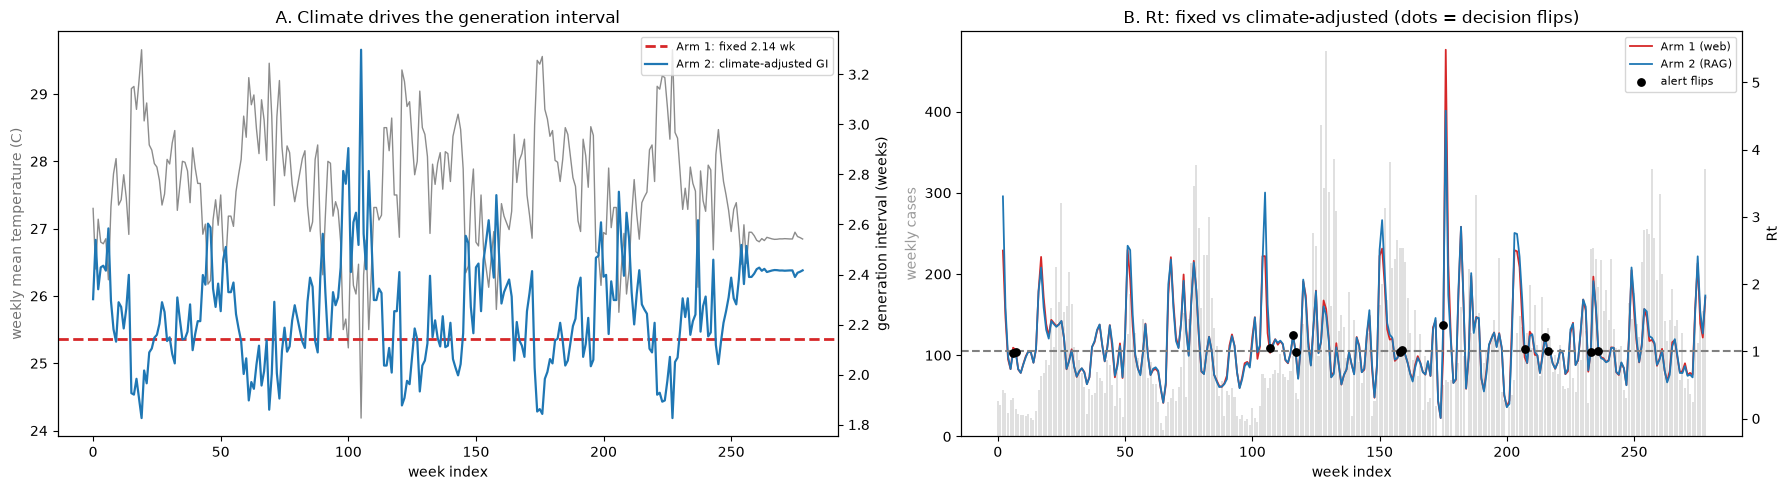

[codecarbon INFO @ 02:18:04] Energy consumed for RAM : 0.009814 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:18:04] Energy consumed for all GPUs : 0.002797 kWh. Total GPU Power : 10.789810697586251 W
[codecarbon INFO @ 02:18:04] Delta energy consumed for CPU with cpu_load : 0.000050 kWh, power : 12.040511198250002 W
[codecarbon INFO @ 02:18:04] Energy consumed for All CPU : 0.003284 kWh
[codecarbon INFO @ 02:18:04] 0.015894 kWh of electricity and 0.000000 L of water were used since the beginning.


In [ ]:
x = np.arange(len(cases))
fig, (axA, axB) = plt.subplots(1, 2, figsize=(18, 5))

# A. temperature -> the two GIs
axA.plot(x, temp, color="0.55", lw=1)
axA.set_ylabel("weekly mean temperature (C)", color="0.45"); axA.set_xlabel("week index")
axA.set_title("A. Climate drives the generation interval")
axA2 = axA.twinx()
axA2.axhline(WEB_GI_DAYS / 7, color="#d62728", lw=2, ls="--", label=f"Arm 1: fixed {WEB_GI_DAYS/7:.2f} wk")
axA2.plot(x, gi_temp_wk, color="#1f77b4", lw=1.6, label="Arm 2: climate-adjusted GI")
axA2.set_ylabel("generation interval (weeks)"); axA2.legend(loc="upper right", fontsize=8)

# B. the two Rt trajectories with alert flips
axB.bar(x, cases, color="0.88")
axB.set_ylabel("weekly cases", color="0.6"); axB.set_xlabel("week index")
axB.set_title("B. Rt: fixed vs climate-adjusted (dots = decision flips)")
axB2 = axB.twinx()
axB2.plot(x, Rt_web, color="#d62728", lw=1.3, label="Arm 1 (web)")
axB2.plot(x, Rt_rag, color="#1f77b4", lw=1.3, label="Arm 2 (RAG)")
axB2.axhline(1.0, color="grey", ls="--")
axB2.scatter(flips, Rt_rag[flips], color="black", zorder=5, s=28, label="alert flips")
axB2.set_ylabel("Rt"); axB2.legend(loc="upper right", fontsize=8)


fig.tight_layout()
fig.savefig("dengue_climate_GI_RAG_vs_web.png", dpi=130)
print("Saved figure -> dengue_climate_GI_RAG_vs_web.png")
plt.show()

In [15]:
emissions = tracker.stop()
print(f"Emissions: {emissions} kg CO₂")

[codecarbon INFO @ 02:18:18] Energy consumed for RAM : 0.009962 kWh. RAM Power : 38.0 W
[codecarbon INFO @ 02:18:18] Energy consumed for all GPUs : 0.002839 kWh. Total GPU Power : 10.779328468303259 W
[codecarbon INFO @ 02:18:18] Delta energy consumed for CPU with cpu_load : 0.000047 kWh, power : 12.031331088000002 W
[codecarbon INFO @ 02:18:18] Energy consumed for All CPU : 0.003331 kWh
[codecarbon INFO @ 02:18:18] 0.016132 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 02:18:18] 0.003467 g.CO2eq/s mean an estimation of 109.34136503242993 kg.CO2eq/year


Emissions: 0.003311466489635044 kg CO₂


# **4. Limitations**

- **The judge inherits LLM biases.** The system prompt encodes dengue biology, but Gemini's knowledge also includes associations from its training data that may not apply to your specific context. Novel outbreaks in non-endemic settings may produce biologically unusual but valid feature patterns that the judge incorrectly flags.

- **Automation bias risk.** Teams may defer to the judge's `approve` verdict without critical thought, especially under time pressure. The judge should be presented as one input among several, not the final authority.

- **Leakage taxonomy is not exhaustive.** Novel leakage patterns (e.g., multicollinearity-based confounding, selection bias in surveillance data) are not in the taxonomy and will not be caught. The taxonomy should be updated as new failure modes are identified in production.

- **Human review is mandatory for public health decisions.** For any model whose outputs could influence a real public health response, domain expert review of the judge's verdict (not just the verdict itself) is required.


### Key Takeaways

- **Structured LLM output enables programmatic validation.** By constraining the judge to a typed Pydantic schema, you can write automated assertions on every verdict, log it to MLflow, and compare across model versions, none of which is possible with free-text output.

- **The judge's value comes from its system prompt.** The biological domain knowledge encoded in the prompt is what distinguishes this from a generic code reviewer. Investing in the quality of the system prompt is investing in the quality of every future judgment.

- **Flawed models with exceptional metrics should raise flags, not earn approval.**


- **The judge pipeline is only as good as its test cases.** Meta-evaluation with deliberately flawed models is how you measure and improve the judge itself. Build a red-teaming test suite with diverse failure modes as the pipeline matures.

### From Notebook to Field: Real-World Implementation Barriers

This tutorial teaches the analytical methodology for climate-sensitive outbreak prediction. It does not teach the institutional, infrastructural, and workforce realities that determine whether such a pipeline ever influences a public health decision. We draw on recent field studies to name those barriers honestly.

**Workforce capacity and response compliance.** A prediction model is only as useful as the response it triggers. Mexico's dengue EWARS, developed with WHO-TDR and validated across multiple states, found that district-level vector control teams showed *highly varied compliance* with response guidelines when outbreak alarms fired even after months of operational testing. The prediction worked; the four-person field team was already managing malaria surveillance, immunization campaigns, and maternal health reporting. Similarly, a 2026 study of dengue surveillance in western India found only 13% of sanctioned district public health laboratories were functional, with field staff facing community resistance, inconsistent lab protocols, and institutional pressure to hit reporting targets rather than act on data [9]

**Data pipeline reality vs. curated datasets.** This tutorial uses clean, pre-linked weekly dataset. In practice, the data integration problem it has already solved is often the hardest part of the pipeline. A systematic review of dengue EWS found that lack of timely, quality data remains the most critical barrier. Climate data are often too coarse for district-level decisions; case counts arrive weeks late and vary in completeness. Ghana's SORMAS deployment was hampered by unreliable internet, unstable power supply, and dependence on external funding for maintenance.
**Silent model drift and the MLOps deficit.** ML models degrade as climate patterns shift, reporting practices change, or new serotypes emerge. Research shows no single drift-detection method generalizes across health use cases, and frequent retraining is impractical in resource-constrained settings. This tutorial introduces LLM-as-judge for validation, but these assume someone monitors performance, interprets drift, and retrains. In most district health offices, that role does not exist.A lot of healthcare AI projects never leave the pilot stage, a pattern called "pilotitis", tools work during the funded period, then quietly degrade and are abandoned.

We highlight these barriers not to discourage ML in outbreak prediction, but to ensure participants understand where their technical skills fit within a larger system. The question "does the model predict accurately?" is necessary but not sufficient. "Who maintains it?", "Who acts on it?", and "What happens when it's wrong?" are equally important and far less amenable to solution by code alone.


<a name="references"></a>
### References




[1] Romanello M, Walawender M, Hsu S-C, et al. The 2024 report of the Lancet Countdown on health and climate change. Lancet. 2024;404(10465):1847–1896. doi:10.1016/S0140-6736(24)01822-1.

[2] IPCC. Climate Change 2023: Synthesis Report (AR6). Geneva: IPCC; 2023. https://www.ipcc.ch/report/ar6/syr/

[3] Chan M, Johansson MA. The incubation periods of dengue viruses. PLoS ONE. 2012;7(11):e50972. doi:10.1371/journal.pone.0050972.

[4] Cori A, Ferguson NM, Fraser C, Cauchemez S. A new framework and software to estimate time-varying reproduction numbers during epidemics. Am J Epidemiol. 2013;178(9):1505–1512.

[5] Codeço CT, Villela DA, Coelho FC. Estimating the effective reproduction number of dengue considering temperature-dependent generation intervals. Epidemics. 2018;25:101–111.

[6] Ong J, Soh S, Ho SH, et al. Fine-scale estimation of effective reproduction numbers for dengue surveillance. PLoS Comput Biol. 2022;18(1):e1009791. doi:10.1371/journal.pcbi.1009791.

[7] Talagala T. colmozzie: Dengue Cases and Climate Variables in Colombo, Sri Lanka (R package). https://github.com/thiyangt/colmozzie

[8] Amazon Web Services. What is Retrieval-Augmented Generation (RAG)? https://aws.amazon.com/what-is/retrieval-augmented-generation/

[9] Sanap V, Sahay S, Martinez-Vega R and Agnihotri S (2026) Informational challenges of dengue surveillance and response. A case study from India. Front. Public Health 14:1809584. doi: 10.3389/fpubh.2026.1809584

[10] The current and future global distribution and population at risk of dengue. Nat Microbiol. 2019;4:1508–1515. doi:10.1038/s41564-019-0476-8.